# Unified Machine Learning Study of Green Corrosion Inhibitors
### From Three Independent Lab Phases to One Rigor-Tested Analytical Framework

This notebook is the **end-to-end narrative record** of this research program: what was done in each
of the three original experimental phases, why they were unified, and every analytical step taken to
make that unification scientifically defensible rather than just computationally convenient.

**How to read this notebook:**
- Sections 1-3 summarize each individual experimental phase as it was originally run.
- Section 4 explains why and how the three phases were merged into one dataset.
- Sections 5-10 walk through the full rigor pipeline: data auditing, formal statistics, cross-phase
  machine learning, and the extended robustness checks (leakage, extrapolation, permutation testing).
- Section 11 gives the final, honest claim-by-claim verdict — what is supported, what is conditional,
  and what is explicitly out of scope.

All code below reads the CSV outputs already produced by the scripts in this folder
(`build_master_dataset.py`, `data_quality_audit.py`, `ea_analysis.py`, `predictor_ablation.py`,
`cross_phase_model_experiments.py`, `rigor_extension.py`) so that this notebook stays fast to run and
focuses on **narrative + result inspection** rather than re-running the full modeling pipeline inline.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 110

HERE = Path.cwd()
ROOT = HERE.parent  # repository root, one level above Unified_Analysis/
FIG_DIR = HERE / "figures"
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    """All figures are saved to Unified_Analysis/figures/ as PNGs, in addition to
    being displayed inline in this notebook, so they can be reused directly on
    the poster without re-running anything."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved: {path}")


---
## Part 1 — The Three Individual Experimental Phases

Before any unification, three separate experimental programs were run in the lab. Each one produced
its own cleaned dataset, its own exploratory analysis, and its own machine learning models. This
section documents what each phase actually did, in its own terms, before we touch the unified work.


### Phase 1 (P1) — Ternary Inhibitor Blend Under Variable Temperature and Time

**Inhibitor system:** a three-component green inhibitor blend — **Bitter Leaf extract (BL)**,
**Plantain Peel extract (PP)**, and **Snail Water (SW)** — formulated in-house.

**Technique:** classical gravimetric **weight loss** (mild steel coupons weighed before/after acid exposure).

This phase itself has **three sub-studies**:

1. **Different Temperature** (`Different Temperature/`): concentration (0-250 ppm) tested across
   **40-80°C** at a fixed exposure time. 30 samples.
2. **Different Time** (`Different Time/`): concentration (0-250 ppm) tested across **25-125 hours**
   at a fixed (room) temperature. 30 samples.
3. **Parent DoE Experiment** (`parent Experiment/`): a **Design-of-Experiment (DoE)** blend-optimization
   study varying the *ratio* of BL/PP/SW (in mL) and exposure time, searching for the blend
   composition that minimizes corrosion rate. 28 runs.

**Original (per-phase) findings:** temperature sub-study best model was an MLP (R²≈0.967 on a small,
clean 30-row dataset); time sub-study best model was Ridge regression (R²≈0.9995); the DoE identified
an optimal blend point at ~1.64 mm/yr corrosion rate, ~87.6% inhibition efficiency.

*(These R² figures were computed with the original per-project modeling setup and standard random
cross-validation — Part 8 of this notebook shows how much lower these numbers become once
leakage-resistant grouped cross-validation is applied.)*


In [2]:
# Raw data preview -- Phase 1 Temperature sub-study
p1_temp = pd.read_excel(ROOT / "Machine learning for predicting corrosion rate and inhibitor efficiency of an optimized ternary inhibitor blend under variable temperatures" / "Different Temperature" / "data_difftime.xlsx")
print("P1-Temperature raw data:", p1_temp.shape)
p1_temp.head()


P1-Temperature raw data: (30, 8)


,concentration (ppm),Initial mass (g),Final mass (g),weight loss (g),weight loss(mg),inhibitor efficiency,Corrosion rate(mm/y),Temperature
0,50,4.8373,4.6667,0.1706,170.6,49.7496,22.136809,40 0C
1,100,4.9029,4.7843,0.1186,118.6,65.0663,15.389365,40 0C
2,150,4.6003,4.5003,0.1000,100.0,70.5449,12.975855,40 0C
3,200,4.8209,4.7369,0.0840,84.0,75.2577,10.899719,40 0C
4,250,5.2779,5.2000,0.0779,77.9,77.0545,10.108191,40 0C


In [3]:
# Raw data preview -- Phase 1 DoE blend-optimization study
p1_doe = pd.read_csv(ROOT / "Machine learning for predicting corrosion rate and inhibitor efficiency of an optimized ternary inhibitor blend under variable temperatures" / "parent Experiment" / "doe_data.csv")
print("P1-DoE raw data:", p1_doe.shape)
p1_doe.head()


P1-DoE raw data: (28, 7)


,Run,BL,PP,SW,Time,IE,CR
0,1,6.5,3.5,5.0,25.0,68.8010,12.48440
1,2,10.0,2.5,2.5,15.0,84.7140,2.02415
2,3,10.0,0.0,5.0,15.0,85.7331,1.88921
3,4,3.0,7.0,5.0,5.0,86.6111,2.73000
4,5,6.5,3.5,5.0,15.0,87.6397,1.63673


### Phase 2 (P2) — Single Green Inhibitor in a Multi-pH, Multi-Temperature Environment

**Inhibitor system:** a single green inhibitor (an earlier screening candidate, tested before the
ternary blend of Phase 1 was formulated).

**Technique:** gravimetric **weight loss**, in **HCl** at three acid strengths (0.5M, 1.0M, 1.5M).

Two sub-studies:

1. **Temperature** (`Temperature/`): concentration (0-450 ppm) x temperature (**30-70°C**) x acid
   molarity, at a fixed 6-hour exposure. 90 rows.
2. **Time** (`Time/`): concentration (0-450 ppm) x exposure time (**3-15 hours**) x acid molarity, at
   room temperature. 90 rows.

**Original (per-phase) findings:** CatBoost was the best corrosion-rate model in both sub-studies
(R²≈0.81-0.90); Random Forest was consistently the best inhibition-efficiency model (R²≈0.95-0.98).
Temperature was the stronger predictor overall; time was comparatively weak.


In [4]:
# Raw data preview -- Phase 2 Temperature sub-study
p2_temp = pd.read_csv(ROOT / "Machine learning prediction of corrosion rate and inhibition efficiency of a green inhibitor in a multi PH and multi temperatre chemical environment" / "Temperature" / "all_temp_cleaned.csv")
print("P2-Temperature raw data:", p2_temp.shape)
p2_temp.head()


P2-Temperature raw data: (90, 11)


,acid_m,time_h,temp_c,temp_k,conc_ppm,initial_weight_g,final_weight_g,wl_g,wl_mg,ie_percent,cr_mm_yr
0,0.5,6,30,303,50,7.177,7.033,0.144,144.0,32.7,15.7
1,0.5,6,30,303,150,7.416,7.284,0.132,132.0,38.3,14.4
2,0.5,6,30,303,250,7.095,7.003,0.092,92.0,57.0,10.0
3,0.5,6,30,303,350,6.595,6.558,0.037,37.0,82.7,4.0
4,0.5,6,30,303,450,6.298,6.278,0.020,19.6,90.8,2.1


### Phase 3 (P3) — Okro Leaf Extract in Acidic vs Basic Media

**Inhibitor system:** Okro (okra, *Abelmoschus esculentus*) leaf extract — tested to check whether a
green inhibitor's performance generalizes to a **fundamentally different medium** (basic, not just acidic).

**Technique:** **Tafel polarization**, an electrochemical technique (not weight loss) — corrosion rate
is derived from measured corrosion current density, with supporting Open-Circuit-Potential (OCP) and
Linear-Sweep-Voltammetry (LSV) measurements.

Two media, each with **17 experimental conditions**:

1. **Acidic** (`Acidic/`): HCl, 1.0-2.5M, inhibitor 50-200 ppm, 30-60°C.
2. **Basic** (`Basic/`): NaOH, 1.0-2.5M, inhibitor 50-200 ppm, 30-60°C.

**Original (per-phase) findings:** even after engineering 22 features (Tafel + OCP + LSV), the best
models reached only R²≈0.2-0.4 (XGBoost in acidic media, MLP in basic media) — much lower than P1/P2,
attributed at the time to the much smaller sample size (17 vs 30-90) and electrochemical measurement noise.


In [5]:
# Raw data preview -- Phase 3 Acidic (Tafel) data
p3_acid = pd.read_csv(ROOT / "Predictive Modeling and Performance Optimization of Okro leaf extract as a corrosion inhibitor in Acidic and Basic Media Using Machine Learning" / "Acidic" / "cleaned data hcl" / "cleaned_HCL_tafel_data.csv")
print("P3-Okro-Acid raw data:", p3_acid.shape)
p3_acid.head()


P3-Okro-Acid raw data: (17, 9)


,Sample,HCl_M,Inhibitor_ppm,Temp_C,E_corr_V,j_corr_A_cm2,I_corr_A,CR_mm_yr,PR_ohm
0,"1.75M,50PPM, 30",1.75,50,30,-0.550265,0.007551,0.007551,87.7385,3.45103
1,"1M, 125PPM, 60",1.00,125,60,-0.500906,0.006739,0.006739,78.3086,3.86661
2,"1M, 125PPM, 30",1.00,125,30,-0.455019,0.005544,0.005544,64.4212,4.70014
3,"1.75M,50PPM, 60",1.75,50,60,-0.457760,0.007380,0.007380,85.7556,3.53083
4,"1M, 200PPM, 45",1.00,200,45,-0.465500,0.003209,0.003209,37.2908,8.11967


---
## Part 2 — Why Unify These Three Phases?

Each phase above is a complete, self-contained study. Individually, they cannot answer questions like:
*"is the temperature sensitivity we see in P1 a coincidence of that particular blend, or a shared
property of green-inhibitor corrosion chemistry?"* Only pooling the raw data — carefully, without
pretending the phases are more comparable than they are — can answer that.

**Four separable research questions** were used instead of one vague compound question:

- **RQ1 (shared chemistry):** Do independently tested green inhibitor systems show consistent
  temperature-dependent corrosion behaviour? *(→ Arrhenius activation-energy comparison, Part 6)*
- **RQ2 (environmental drivers):** How does the dominant predictor of corrosion rate change across
  temperature, time, concentration, and medium? *(→ 3-layer predictor-dominance evidence, Part 7)*
- **RQ3 (cross-phase generalization):** Can a model trained on some phases predict a phase it has
  never seen? *(→ Models A-G and leave-one-phase-out, Part 8)*
- **RQ4 (measurement robustness):** How does switching from gravimetric weight loss to electrochemical
  Tafel measurement affect predictive reliability? *(→ Part 8-9)*

Two explicit ground rules were applied throughout, based on early critique of this work:

1. **Same-lab does not mean statistically interchangeable.** P1, P2, and P3 differ in inhibitor
   chemistry, technique, medium, dosage units, and sample size — every one of those differences is
   modeled explicitly, never assumed away.
2. **P1 and P2 (weight loss) are Tier-1 evidence; P3 (Tafel, n=17/medium) is Tier-2, exploratory
   evidence** used mainly as a stress-test of the framework, not as an equal partner in headline claims.

The full question-by-question defense of this approach lives in
[`REVIEWER_CHALLENGES.md`](../REVIEWER_CHALLENGES.md) — this notebook narrates the same work with the
actual numbers inline.


---
## Part 3 — Building the Unified Master Dataset

`build_master_dataset.py` reads all seven raw sub-phase files (P1-Temperature, P1-Time, P1-DoE-Blend,
P2-Temperature, P2-Time, P3-Okro-Acid, P3-Okro-Basic) and harmonizes them into one long-format table.

**The schema was designed to prevent a specific mistake**: P1's DoE sub-study doses its blend in
**mL** (total BL+PP+SW volume), while every other sub-study doses in **ppm**. An early draft of this
pipeline stored both in the same `Concentration_ppm` column — a real bug. The corrected schema uses:

- **`Dose_Value`** — always populated, in the study's own native unit.
- **`Dose_Unit`** — `'ppm'` or `'mL_blend'`.
- **`Concentration_ppm`** — populated **only** where `Dose_Unit == 'ppm'`; `NaN` for the DoE rows.
- **`Phase_Group`** — `P1` / `P2` / `P3`, used throughout the cross-phase ML experiments.

This makes it *structurally impossible* for a downstream analysis to accidentally rank a mL-dosed row
against a ppm-dosed row — the dosage-efficiency function filters on `Dose_Unit` before computing anything.


In [6]:
master = pd.read_csv(ROOT / "Unified_Analysis" / "master_corrosion_dataset.csv")
print(f"Master dataset: {master.shape[0]} rows x {master.shape[1]} columns")
master["Study"].value_counts()


Master dataset: 302 rows x 13 columns


Study
P2-Temperature    90
P2-Time           90
P1-Temperature    30
P1-Time           30
P1-DoE-Blend      28
P3-Okro-Acid      17
P3-Okro-Basic     17
Name: count, dtype: int64

In [7]:
# Confirm the dose-unit separation is enforced -- only P1-DoE-Blend uses mL_blend
master.groupby(["Dose_Unit", "Study"]).size()


Dose_Unit  Study         
mL_blend   P1-DoE-Blend      28
ppm        P1-Temperature    30
           P1-Time           30
           P2-Temperature    90
           P2-Time           90
           P3-Okro-Acid      17
           P3-Okro-Basic     17
dtype: int64

---
## Part 4 — Data-Quality and Comparability Audit

Before any statistics or modeling, `data_quality_audit.py` runs a full pre-model audit: missingness,
duplicate rows, non-positive corrosion-rate values, and an explicit **comparability matrix** stating
which dimensions are actually shared across P1/P2/P3 and which are not.

**Key statement made explicit in this audit (the "unit of independence"):** each of the 302 rows is
one measurement under a specific condition, not an independently repeated full experiment — e.g. P2's
90 rows come from 30 unique conditions × 3 replicate measurements each, a structured design. This
directly motivates using **grouped cross-validation** later (Part 8), not plain random k-fold.


In [8]:
audit = pd.read_csv(ROOT / "Unified_Analysis" / "data_quality_audit.csv")
audit


,Study,Phase_Group,n,n_missing_Temp_C,n_missing_Time_h,n_missing_IE_percent,n_duplicate_rows,n_CR_le_0,CR_min,CR_max,CR_mean,CR_std,unique_Temp_levels,unique_Dose_levels,unique_Time_levels
0,P1-DoE-Blend,P1,28,28,0,0,0,0,1.636730,12.900000,3.739314,3.733004,0,1,7
1,P1-Temperature,P1,30,0,30,1,0,0,10.108191,231.709850,97.408449,82.552411,5,6,0
2,P1-Time,P1,30,30,0,0,0,0,2.359011,19.837488,5.600441,5.422245,0,6,5
3,P2-Temperature,P2,90,0,0,15,0,0,2.100000,513.400000,111.724444,123.179651,5,6,1
4,P2-Time,P2,90,90,0,15,0,0,2.000000,99.900000,15.524444,15.165627,0,6,5
5,P3-Okro-Acid,P3,17,0,17,17,0,0,35.068100,124.736000,84.111140,26.184661,3,3,0
6,P3-Okro-Basic,P3,17,0,17,17,0,5,-42.073200,885.788000,71.534570,213.430023,3,3,0


In [9]:
comparability = pd.read_csv(ROOT / "Unified_Analysis" / "comparability_matrix.csv")
comparability


,Dimension,P1,P2,P3,Comparable
0,Material,Mild steel,Mild steel,Mild steel,Yes
1,Corrosion target,CR (mm/yr),CR (mm/yr),CR (mm/yr),Yes
2,Measurement technique,Weight loss,Weight loss,Tafel (electrochemical),Partial (P1/P2 only)
3,Inhibitor system,BL+PP+SW ternary blend,Single green inhibitor,Okro leaf extract,No -- different chemistries
4,Medium,HCl (1M),HCl (0.5-1.5M),HCl and NaOH (1.0-2.5M),Partial (acid only across all 3)
5,Temperature range,40-80C,30-70C,30-60C,Partial overlap (30-60C)
6,Dose unit,ppm (Temp/Time sub-studies) / mL_blend (DoE),ppm,ppm,No -- DoE not comparable to ppm studies
7,Time range,25-125h (Time sub-study),3-15h (Time sub-study),not varied (fixed/short),No -- different designs
8,Sample size (n),~30-90 per sub-phase,~90 per sub-phase,17 per medium,No -- P3 much smaller


**Non-positive corrosion-rate rows** were flagged, not silently deleted: exactly **5 rows, all in
P3-Okro-Basic**, show near-zero or negative corrosion rates — an artifact of noisy Tafel current
measurements at those specific conditions. They remain in the master dataset and are excluded only
from analyses that mathematically require CR > 0 (the Arrhenius fit below).

---
## Part 5 — Correlations, Recomputed Fresh From Raw Data

Rather than copying correlation figures from the three original per-project summary reports (which
used different methods/precision), correlations between corrosion rate and Temperature / Time / Dose
were recomputed identically for every phase from the unified raw data.


In [10]:
corr = pd.read_csv(ROOT / "Unified_Analysis" / "correlation_comparison.csv")
corr


,Study,n,r_CR_vs_Temp,r_CR_vs_Time,r_CR_vs_Dose,Dose_Unit
0,P1-DoE-Blend,28,NaN,0.598228,NaN,mL_blend
1,P1-Temperature,30,0.906820,NaN,-0.241123,ppm
2,P1-Time,30,NaN,-0.013925,-0.696199,ppm
3,P2-Temperature,90,0.770163,NaN,-0.170144,ppm
4,P2-Time,90,NaN,-0.222660,-0.586821,ppm
5,P3-Okro-Acid,17,0.336419,NaN,-0.349899,ppm
6,P3-Okro-Basic,17,-0.376763,NaN,0.049629,ppm


**Visual — which variable correlates most strongly with corrosion rate, per phase.** Temperature (red) is
clearly the largest bar in the two temperature-varying gravimetric phases; dose (blue) dominates in the
two time-varying phases. P3's bars are small and mixed in sign in both media — visually confirming the
"conditional, not universal" conclusion from Part 7.

Saved: c:\Users\FOGBOI\Documents\GitHub\DSN-POSTER\Unified_Analysis\figures\01_correlation_by_phase.png


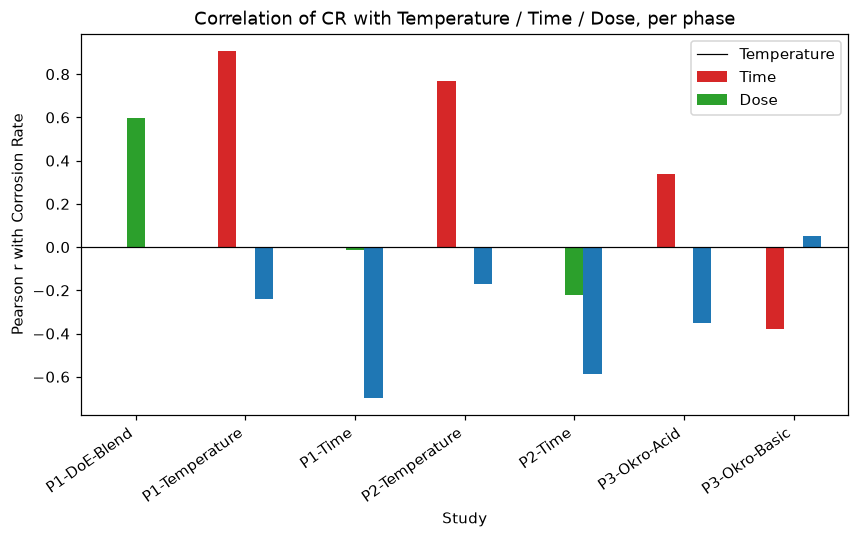

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = corr.set_index("Study")[["r_CR_vs_Temp", "r_CR_vs_Time", "r_CR_vs_Dose"]]
plot_df.plot(kind="bar", ax=ax, color=["#d62728", "#2ca02c", "#1f77b4"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Pearson r with Corrosion Rate")
ax.set_title("Correlation of CR with Temperature / Time / Dose, per phase")
ax.legend(["Temperature", "Time", "Dose"], loc="upper right")
plt.xticks(rotation=35, ha="right")
save_fig(fig, "01_correlation_by_phase")
plt.show()


Temperature dominates in the two temperature-varying phases (P1: r=0.907, P2: r=0.770); dose
dominates in the two time-varying phases (P1-Time: r=-0.696, P2-Time: r=-0.587). P3's correlations are
weaker and mixed in sign across media — this pattern is investigated formally in Part 7.

---
## Part 6 — Formal Activation-Energy (Ea) Comparison: The Headline Finding

`ea_analysis.py` fits the Arrhenius equation (ln(CR) vs 1/T) **per dose group**, then compares the
resulting activation energies between **P1 and P2 only** — the two independently formulated
gravimetric inhibitor systems. P3 is deliberately excluded from this specific comparison (see below).


In [12]:
ea = pd.read_csv(ROOT / "Unified_Analysis" / "arrhenius_activation_energy.csv")
ea


,Study,n_dose_groups,Ea_mean_kJ_mol,Ea_std_kJ_mol,Ea_values_kJ_mol
0,P1-Temperature,6,61.109665,9.648769,"[np.float64(42.42), np.float64(56.14), np.floa..."
1,P2-Temperature,6,66.514928,15.139141,"[np.float64(45.36), np.float64(54.25), np.floa..."
2,P3-Okro-Acid,4,11.223893,9.678820,"[np.float64(5.46), np.float64(-0.64), np.float..."
3,P3-Okro-Basic,3,-180.188213,513.436777,"[np.float64(76.43), np.float64(279.75), np.flo..."


In [14]:
ea_comparison = pd.read_csv(ROOT / "Unified_Analysis" / "ea_comparison.csv")
ea_comparison.T


,0
P1_Ea_mean,61.11
P1_Ea_std,10.571823
P1_n_dose_groups,6
P2_Ea_mean,66.516667
P2_Ea_std,16.583376
P2_n_dose_groups,6
difference_kJ_mol,5.406667
SE_of_difference,8.028821
welch_t_stat,-0.673407
welch_p_value,0.518601


**Hero figure — the strongest single result in this study.** Error bars show ± 1 SD across each phase's
6 dose-group Ea fits. The bars overlap substantially, and the annotated p-values (both > 0.05) confirm
this is not just a visual impression: the two independently formulated inhibitor systems are **not
statistically distinguishable** in activation energy.

Saved: c:\Users\FOGBOI\Documents\GitHub\DSN-POSTER\Unified_Analysis\figures\02_ea_convergence_headline.png


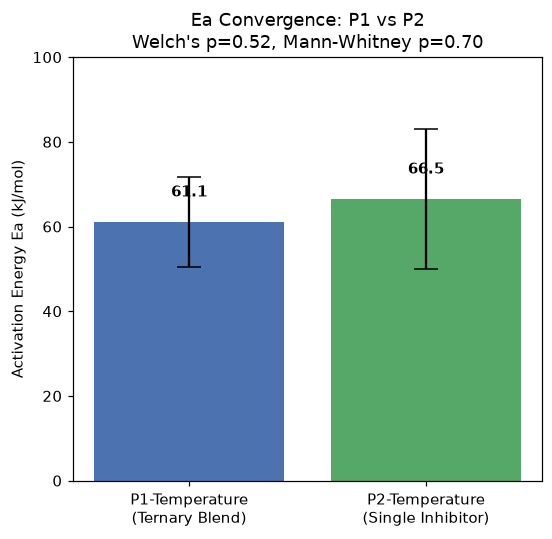

In [15]:
row = ea_comparison.iloc[0]
fig, ax = plt.subplots(figsize=(5.5, 5))
means = [row["P1_Ea_mean"], row["P2_Ea_mean"]]
stds = [row["P1_Ea_std"], row["P2_Ea_std"]]
bars = ax.bar(["P1-Temperature\n(Ternary Blend)", "P2-Temperature\n(Single Inhibitor)"], means,
              yerr=stds, capsize=8, color=["#4c72b0", "#55a868"])
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m + 6, f"{m:.1f}", ha="center", fontweight="bold")
ax.set_ylabel("Activation Energy Ea (kJ/mol)")
ax.set_title(f"Ea Convergence: P1 vs P2\nWelch's p={row['welch_p_value']:.2f}, "
             f"Mann-Whitney p={row['mannwhitney_p_value']:.2f}")
ax.set_ylim(0, 100)
save_fig(fig, "02_ea_convergence_headline")
plt.show()


**Result:** P1 Ea = 61.1 ± 10.6 kJ/mol, P2 Ea = 66.5 ± 16.6 kJ/mol. A **Welch's t-test** (p=0.52)
and **Mann-Whitney U test** (p=0.70) both find these estimates **not statistically distinguishable**
within their uncertainty — not just "the numbers look close," but a formal test. A leave-one-dose-group-out
sensitivity check (below) confirms this convergence is not driven by a single outlier dose group.

In [16]:
ea_sensitivity = pd.read_csv(ROOT / "Unified_Analysis" / "ea_sensitivity.csv")
ea_sensitivity


,Phase,excluded_index,excluded_value,jackknife_mean_Ea,n_remaining
0,P1-Temperature,0,42.42,64.848,5
1,P1-Temperature,1,56.14,62.104,5
2,P1-Temperature,2,62.13,60.906,5
3,P1-Temperature,3,66.12,60.108,5
4,P1-Temperature,4,68.65,59.602,5
5,P1-Temperature,5,71.20,59.092,5
6,P2-Temperature,0,45.36,70.748,5
7,P2-Temperature,1,54.25,68.970,5
8,P2-Temperature,2,60.30,67.760,5
9,P2-Temperature,3,70.12,65.796,5


**Visual — stability check.** Both lines stay flat regardless of which dose group is excluded: no single
dose group is responsible for the P1/P2 Ea convergence shown above.

Saved: c:\Users\FOGBOI\Documents\GitHub\DSN-POSTER\Unified_Analysis\figures\03_ea_jackknife_sensitivity.png


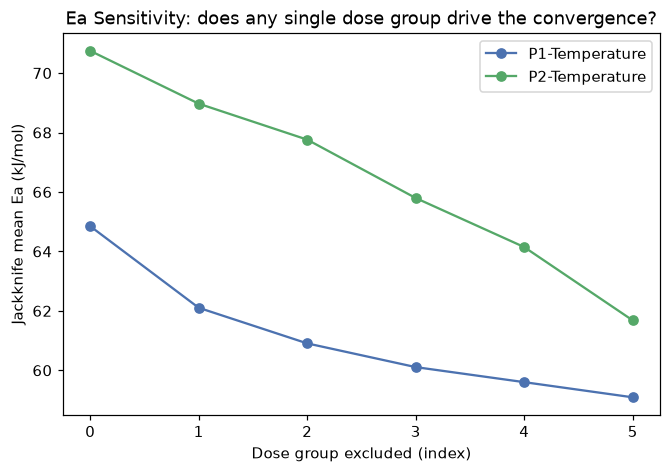

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for phase, color in [("P1-Temperature", "#4c72b0"), ("P2-Temperature", "#55a868")]:
    sub = ea_sensitivity[ea_sensitivity.Phase == phase]
    ax.plot(sub["excluded_index"], sub["jackknife_mean_Ea"], "o-", color=color, label=phase)
ax.set_xlabel("Dose group excluded (index)")
ax.set_ylabel("Jackknife mean Ea (kJ/mol)")
ax.set_title("Ea Sensitivity: does any single dose group drive the convergence?")
ax.legend()
save_fig(fig, "03_ea_jackknife_sensitivity")
plt.show()


**Why P3 is excluded from this headline claim:** its own per-dose-group Ea fits are wildly
inconsistent — P3-Okro-Basic's three dose-group fits are -897, +76, and +280 kJ/mol, averaging to a
physically nonsensical -180 ± 513 kJ/mol. It is excluded **because its own fit variance is too large
to trust**, not because it happens to disagree with P1/P2.

**Interpretation discipline applied:** the convergence is described as *"consistent with an inhibition
mechanism dominated by surface coverage/adsorption rather than a substantial alteration of the apparent
corrosion reaction barrier"* — not as proof of a specific mechanism, since no adsorption isotherm was
measured in either phase.

---
## Part 7 — Three-Layer Predictor-Dominance Evidence

A predictor is only called "dominant" here if **three independent layers of evidence agree**:
(1) Pearson correlation, (2) permutation importance from a fitted Random Forest, and (3) the R² drop
observed when that feature is removed from the model (ablation). This is deliberately stricter than
relying on correlation alone.


In [18]:
ablation = pd.read_csv(ROOT / "Unified_Analysis" / "predictor_ablation.csv")
ablation


,Study,Feature,n,full_model_R2,permutation_importance,R2_drop_when_removed
0,P1-Temperature,Dose_Value,30,0.876965,0.143135,0.245846
1,P1-Temperature,Temp_C,30,0.876965,1.879080,3.739666
2,P2-Temperature,Dose_Value,90,0.882383,0.068028,0.077543
3,P2-Temperature,Temp_C,90,0.882383,1.795601,3.784501
4,P2-Temperature,Molarity_M,90,0.882383,0.469894,0.396849
5,P3-Okro-Acid,Dose_Value,17,-0.339135,0.425465,0.609255
6,P3-Okro-Acid,Temp_C,17,-0.339135,0.595133,0.594612
7,P3-Okro-Acid,Molarity_M,17,-0.339135,0.314165,-0.209257
8,P3-Okro-Basic,Dose_Value,17,-1108.418016,0.040988,-511.577498
9,P3-Okro-Basic,Temp_C,17,-1108.418016,0.873751,1456.309254


**Visual — Layer 2 of the 3-layer evidence chain.** Temp_C towers over the other features for
P1-Temperature and P2-Temperature; for both P3 media, no single feature dominates the way Temp_C does
in P1/P2 — visually reinforcing why P3 is classified as "mixed / no dominant factor."

Saved: c:\Users\FOGBOI\Documents\GitHub\DSN-POSTER\Unified_Analysis\figures\04_permutation_importance_by_phase.png


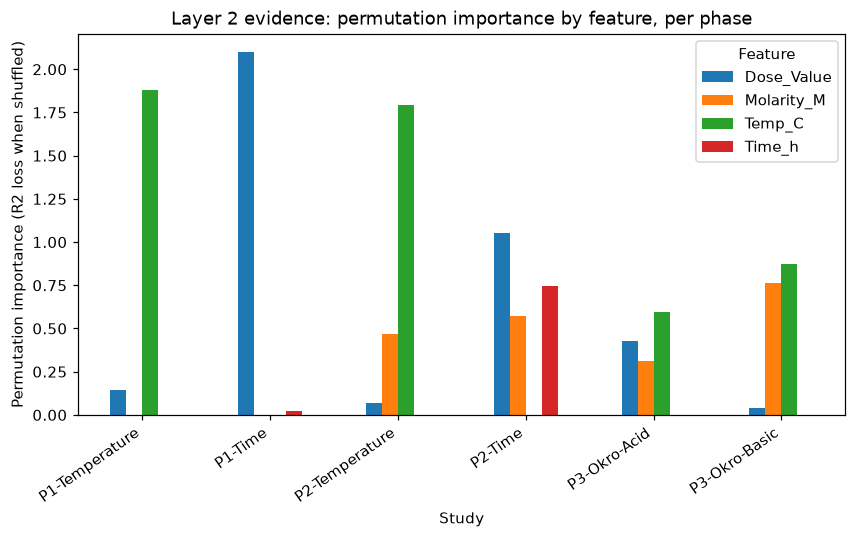

In [19]:
pivot = ablation.pivot_table(index="Study", columns="Feature", values="permutation_importance")
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Permutation importance (R2 loss when shuffled)")
ax.set_title("Layer 2 evidence: permutation importance by feature, per phase")
plt.xticks(rotation=35, ha="right")
save_fig(fig, "04_permutation_importance_by_phase")
plt.show()


**Result:** all three layers agree that **temperature dominates in P1-Temperature and
P2-Temperature**. For **P3 (both media), the three layers disagree** on which factor dominates — so no
"dominant factor" is claimed there. This is the evidence behind RQ2's answer: temperature dominance is
conditional on the gravimetric phases, not universal.

In [20]:
interactions = pd.read_csv(ROOT / "Unified_Analysis" / "interaction_effects.csv")
interactions


,Study,n,interaction_coef,interaction_p_value,interaction_significant,model_R2
0,P1-Temperature,30,-0.002249,0.624198,False,0.881583
1,P2-Temperature,90,-0.002143,0.553075,False,0.623651


An OLS interaction test (`Dose_Value × Temp_C`) found **no significant interaction** in either
gravimetric temperature phase (P1: p=0.62; P2: p=0.55) — concentration does not measurably modify the
temperature effect in these phases.

---
## Part 8 — Cross-Phase Machine Learning: Models A-G

`cross_phase_model_experiments.py` builds seven model configurations —
**A**=P1 only, **B**=P2 only, **C**=P3 only, **D**=P1+P2, **E**=P1+P2+P3, and two phase-identity
ablations **F**=P1+P2 (identity features removed) and **G**=P1+P2+P3 (identity features removed) —
each evaluated with **4 model families** (Ridge, Random Forest, XGBoost, CatBoost) under **2 validation
schemes** (standard random 5-fold CV, and grouped 5-fold CV that respects experimental-condition groups).


In [21]:
leaderboard = pd.read_csv(ROOT / "Unified_Analysis" / "model_leaderboard.csv")
leaderboard.sort_values(["Config", "Model", "CV_scheme"]).reset_index(drop=True)


,Config,Model,n,CV_scheme,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,n_folds
0,A_P1,CatBoost,88,grouped_5fold,0.571457,0.191125,15.664454,10.235347,27.860581,19.319384,5
1,A_P1,CatBoost,88,standard_5fold,0.964593,0.038908,5.427845,3.204539,10.888474,7.569515,5
2,A_P1,RandomForest,88,grouped_5fold,0.447627,0.334491,16.762316,10.363807,29.691907,18.762889,5
3,A_P1,RandomForest,88,standard_5fold,0.973517,0.018978,4.923624,2.587979,10.016410,4.769597,5
4,A_P1,Ridge,88,grouped_5fold,-1.664492,4.627435,18.783096,4.740008,27.606993,9.111147,5
5,A_P1,Ridge,88,standard_5fold,0.910973,0.029489,12.865300,2.418886,18.259057,3.699790,5
6,A_P1,XGBoost,88,grouped_5fold,0.372019,0.387685,17.809639,10.266869,31.736572,18.978223,5
7,A_P1,XGBoost,88,standard_5fold,0.982727,0.009391,3.945696,1.580046,7.925496,3.098028,5
8,B_P2,CatBoost,180,grouped_5fold,0.268554,0.122298,35.513630,29.365601,50.528947,43.682532,5
9,B_P2,CatBoost,180,standard_5fold,0.965970,0.016026,9.068236,2.417276,17.213726,5.308906,5


### The leakage finding

This is arguably the single most important methodological result in this whole study: **standard
random cross-validation substantially overestimates performance** once the experimental-condition
grouping (Part 4) is respected instead.

In [22]:
leak_check = leaderboard.pivot_table(index=["Config", "Model"], columns="CV_scheme", values="R2_mean").reset_index()
leak_check["R2_drop_from_grouping"] = leak_check["standard_5fold"] - leak_check["grouped_5fold"]
leak_check.sort_values("R2_drop_from_grouping", ascending=False).head(10)


CV_scheme,Config,Model,grouped_5fold,standard_5fold,R2_drop_from_grouping
11,C_P3,XGBoost,-20.620747,-9.535979,11.084768
9,C_P3,RandomForest,-9.239203,-3.547648,5.691555
6,B_P2,Ridge,-3.801215,0.697933,4.499148
8,C_P3,CatBoost,-5.104036,-1.614484,3.489552
2,A_P1,Ridge,-1.664492,0.910973,2.575465
10,C_P3,Ridge,-5.060801,-3.442961,1.617840
18,E_P1P2P3,Ridge,-0.985427,0.497846,1.483273
26,G_P1P2P3_noIdentity,Ridge,-0.841902,0.513566,1.355468
5,B_P2,RandomForest,-0.235816,0.964930,1.200746
21,F_P1P2_noIdentity,RandomForest,-0.178136,0.940174,1.118309


Saved: c:\Users\FOGBOI\Documents\GitHub\DSN-POSTER\Unified_Analysis\figures\05_standard_vs_grouped_cv.png


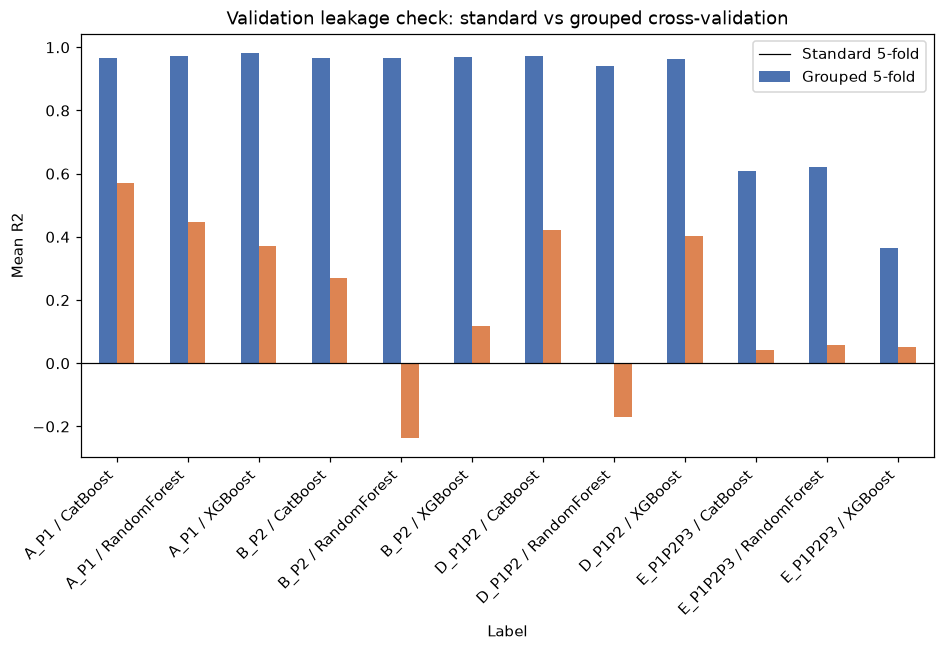

In [23]:
plot_df = leak_check[(leak_check["Config"].isin(["A_P1", "B_P2", "D_P1P2", "E_P1P2P3"])) &
                    (leak_check["Model"].isin(["RandomForest", "CatBoost", "XGBoost"]))].copy()
plot_df["Label"] = plot_df["Config"] + " / " + plot_df["Model"]
fig, ax = plt.subplots(figsize=(10, 5))
plot_df.set_index("Label")[["standard_5fold", "grouped_5fold"]].plot(kind="bar", ax=ax,
    color=["#4c72b0", "#dd8452"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean R2")
ax.set_title("Validation leakage check: standard vs grouped cross-validation")
plt.xticks(rotation=45, ha="right")
ax.legend(["Standard 5-fold", "Grouped 5-fold"])
save_fig(fig, "05_standard_vs_grouped_cv")
plt.show()


Some standard-CV R² figures above 0.95 collapse to near-zero or negative once grouped CV is
applied. Any historical R² figures from the original per-phase notebooks (Part 1) should be read with
this caveat — they were almost certainly computed the same (leakier) way.

### Is the model learning corrosion physics, or just "which experiment"?

Comparing the full models (D, E — which include `Technique`/`Medium_Type`/`Inhibitor_System`) against
the identity-ablated models (F, G — with those columns removed) tests this directly.

In [24]:
identity_ablation = pd.read_csv(ROOT / "Unified_Analysis" / "phase_identity_ablation.csv")
identity_ablation


,Full_config,Reduced_config,Model,CV_scheme,Full_R2,Reduced_R2,R2_drop_from_removing_identity
0,D_P1P2,F_P1P2_noIdentity,Ridge,standard_5fold,0.719454,0.718246,0.001208
1,D_P1P2,F_P1P2_noIdentity,RandomForest,standard_5fold,0.941007,0.940174,0.000834
2,D_P1P2,F_P1P2_noIdentity,XGBoost,standard_5fold,0.964192,0.966781,-0.002589
3,D_P1P2,F_P1P2_noIdentity,CatBoost,standard_5fold,0.971004,0.970733,0.000271
4,D_P1P2,F_P1P2_noIdentity,Ridge,grouped_5fold,-0.318588,-0.316937,-0.001651
5,D_P1P2,F_P1P2_noIdentity,RandomForest,grouped_5fold,-0.168982,-0.178136,0.009153
6,D_P1P2,F_P1P2_noIdentity,XGBoost,grouped_5fold,0.403825,0.401885,0.001941
7,D_P1P2,F_P1P2_noIdentity,CatBoost,grouped_5fold,0.420603,0.447881,-0.027278
8,E_P1P2P3,G_P1P2P3_noIdentity,Ridge,standard_5fold,0.497846,0.513566,-0.015721
9,E_P1P2P3,G_P1P2P3_noIdentity,RandomForest,standard_5fold,0.620369,0.608311,0.012058


In [25]:
identity_share = pd.read_csv(ROOT / "Unified_Analysis" / "phase_identity_permutation_share.csv")
identity_share


,Config,identity_feature_importance_share
0,D_P1P2,0.012399
1,E_P1P2P3,0.059589


Identity features carry only **~1.2%** of permutation importance in the P1+P2 model (same
technique, same acid family — the model is learning from real environmental variables) but **~6.0%**
once P3 (a different technique) is added — most plausibly because those features help the model
recognize the very different Tafel measurement scale, not because it is "cheating" on inhibitor identity.

### Does adding P3 help or hurt pooled prediction?

In [26]:
p1p2_vs_all = pd.read_csv(ROOT / "Unified_Analysis" / "p1p2_vs_p1p2p3.csv")
p1p2_vs_all


,Model,CV_scheme,P1P2_R2,P1P2P3_R2,P1P2_MAE,P1P2P3_MAE,R2_change_from_adding_P3,MAE_change_from_adding_P3
0,Ridge,standard_5fold,0.719454,0.497846,28.271712,35.756890,-0.221608,7.485178
1,RandomForest,standard_5fold,0.941007,0.620369,11.624955,17.021429,-0.320638,5.396474
2,XGBoost,standard_5fold,0.964192,0.363871,8.150933,15.453198,-0.600321,7.302265
3,CatBoost,standard_5fold,0.971004,0.607912,7.192124,14.858253,-0.363092,7.666129
4,Ridge,grouped_5fold,-0.318588,-0.985427,35.085695,42.153565,-0.666839,7.067870
5,RandomForest,grouped_5fold,-0.168982,0.056523,35.131663,36.512749,0.225505,1.381086
6,XGBoost,grouped_5fold,0.403825,0.051599,28.486419,35.239297,-0.352226,6.752878
7,CatBoost,grouped_5fold,0.420603,0.041030,29.289842,32.827503,-0.379573,3.537661


Adding P3 **hurts** performance in 6 of 8 model×CV-scheme comparisons — consistent with P3
representing a genuine distribution/measurement-regime shift rather than transferable extra signal.
This is reported as a legitimate, informative result, not a pipeline failure.

### Leave-one-phase-out: the real generalization test

Train on two phases, test entirely on the third — a phase the model has never seen at all.

In [27]:
lopo = pd.read_csv(ROOT / "Unified_Analysis" / "leave_one_phase_out_results.csv")
lopo


,Train_phases,Test_phase,Model,Train_n,Test_n,R2,MAE,RMSE,Train_CR_mean,Train_CR_std,Test_CR_mean,Test_CR_std,Test_has_unseen_Inhibitor_System
0,P1+P2,P3,Ridge,268,34,-0.403331,96.713975,174.901877,54.654356,90.778827,77.822855,149.863839,True
1,P1+P2,P3,RandomForest,268,34,-0.342763,93.363713,171.085848,54.654356,90.778827,77.822855,149.863839,True
2,P1+P2,P3,XGBoost,268,34,-0.359811,92.801381,172.168475,54.654356,90.778827,77.822855,149.863839,True
3,P1+P2,P3,CatBoost,268,34,-0.235619,83.665386,164.118188,54.654356,90.778827,77.822855,149.863839,True
4,P1+P3,P2,Ridge,122,180,0.101225,61.293079,94.469685,47.876595,97.585360,63.624444,99.925576,True
5,P1+P3,P2,RandomForest,122,180,0.331825,40.635921,81.453919,47.876595,97.585360,63.624444,99.925576,True
6,P1+P3,P2,XGBoost,122,180,0.400194,40.028408,77.174209,47.876595,97.585360,63.624444,99.925576,True
7,P1+P3,P2,CatBoost,122,180,0.324289,43.271264,81.912005,47.876595,97.585360,63.624444,99.925576,True
8,P2+P3,P1,Ridge,214,88,0.568089,34.186169,42.548038,65.880267,109.077534,36.306449,65.112432,True
9,P2+P3,P1,RandomForest,214,88,0.212687,39.998317,57.445490,65.880267,109.077534,36.306449,65.112432,True


Saved: c:\Users\FOGBOI\Documents\GitHub\DSN-POSTER\Unified_Analysis\figures\06_leave_one_phase_out_transfer.png


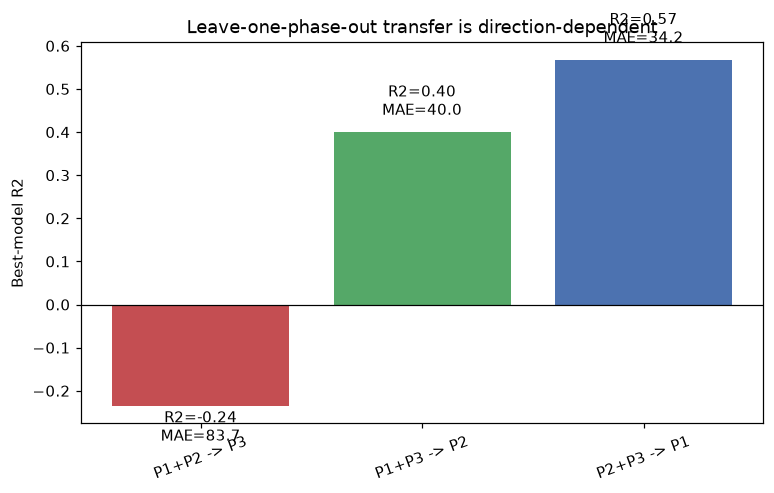

In [28]:
lopo_plot = lopo.copy()
lopo_plot["Direction"] = lopo_plot["Train_phases"] + " -> " + lopo_plot["Test_phase"]
lopo_best = lopo_plot.loc[lopo_plot.groupby("Direction")["R2"].idxmax()]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(lopo_best["Direction"], lopo_best["R2"], color=["#c44e52", "#55a868", "#4c72b0"])
ax.axhline(0, color="black", linewidth=0.8)
for i, (_, r) in enumerate(lopo_best.iterrows()):
    ax.text(i, r["R2"] + (0.04 if r["R2"] >= 0 else -0.08),
            f"R2={r['R2']:.2f}\nMAE={r['MAE']:.1f}", ha="center")
ax.set_ylabel("Best-model R2")
ax.set_title("Leave-one-phase-out transfer is direction-dependent")
plt.xticks(rotation=20)
save_fig(fig, "06_leave_one_phase_out_transfer")
plt.show()


Transfer is **direction-dependent**: models trained on gravimetric data (P1+P2) cannot predict
Tafel data (P3) at all (negative R² for every model). Models trained with some Tafel data included
transfer moderately well to gravimetric phases (up to R²=0.57 for P2+P3→P1). Part 9 explains this
asymmetry directly via interpolation vs extrapolation.

---
## Part 9 — Extended Rigor Checks

A second rigor pass (`rigor_extension.py`) closes several remaining gaps: experimental-series
dependence, interpolation vs extrapolation, target-construction leakage, a permutation/null sanity
check, repeated-CV stability, error stratification, and a model-simplicity test.


### 9.1 — Experimental-series / replicate structure

Confirms *why* grouped CV (Part 8) was necessary, not just a precaution.

In [29]:
replicates = pd.read_csv(ROOT / "Unified_Analysis" / "replicate_structure.csv")
replicates


,Study,n_rows,n_condition_groups,n_groups_with_replicates,max_replicates_in_a_group,mean_rows_per_group
0,P1-DoE-Blend,28,7,5,9,4.000000
1,P1-Temperature,30,30,0,1,1.000000
2,P1-Time,30,30,0,1,1.000000
3,P2-Temperature,90,30,30,3,3.000000
4,P2-Time,90,30,30,3,3.000000
5,P3-Okro-Acid,17,9,5,5,1.888889
6,P3-Okro-Basic,17,9,5,5,1.888889


**P2's 90 rows are exactly 30 unique conditions × 3 replicate measurements each** — a textbook
case where naive random CV would leak replicate measurements of the same condition across train/test.

### 9.2 — Interpolation vs extrapolation

Characterizes, for every leave-one-phase-out direction, whether the held-out phase's conditions fall
*within* the training phases' range (interpolation) or *beyond* it (extrapolation).

In [30]:
interp_extrap = pd.read_csv(ROOT / "Unified_Analysis" / "interpolation_extrapolation.csv")
interp_extrap


,Train,Test,Variable,Train_min,Train_max,Test_min,Test_max,Classification
0,P1+P2,P3,Dose_Value,0.0,450.0,50.0,200.0,interpolation
1,P1+P2,P3,Temp_C,30.0,80.0,30.0,60.0,interpolation
2,P1+P2,P3,Molarity_M,0.5,1.5,1.0,2.5,extrapolation
3,P1+P2,P3,Medium_Type,NaN,NaN,NaN,NaN,extrapolation (unseen media: {'Basic'})
4,P1+P3,P2,Dose_Value,0.0,250.0,0.0,450.0,extrapolation
5,P1+P3,P2,Temp_C,30.0,80.0,30.0,70.0,interpolation
6,P1+P3,P2,Time_h,5.0,125.0,3.0,15.0,extrapolation
7,P1+P3,P2,Molarity_M,1.0,2.5,0.5,1.5,extrapolation
8,P1+P3,P2,Medium_Type,NaN,NaN,NaN,NaN,interpolation
9,P2+P3,P1,Dose_Value,0.0,450.0,0.0,250.0,interpolation


This explains the LOPO pattern from Part 8 directly: **P1+P2 → P3 fails** because it requires
extrapolating in Molarity *and* an entirely unseen medium (Basic/NaOH) simultaneously. **P2+P3 → P1**
(the best-performing direction) only requires extrapolating Temperature and Time, not Dose, Molarity,
or Medium.

### 9.3 — Target-construction / leakage audit

Traces whether `IE_percent` is mathematically derived from `CR_mm_yr` — if so, it must never be used
as a *feature* when predicting CR (it already isn't, in this pipeline's feature list).

In [31]:
leakage_audit = pd.read_csv(ROOT / "Unified_Analysis" / "target_leakage_audit.csv")
print(f"n comparisons = {len(leakage_audit)}, mean abs diff = {leakage_audit['abs_diff'].mean():.3f} percentage points")
leakage_audit.head()


n comparisons = 150, mean abs diff = 0.073 percentage points


,Study,Dose_Value,actual_IE,predicted_IE_from_CR,abs_diff
0,P2-Temperature,50.0,32.7,32.618026,0.081974
1,P2-Temperature,150.0,38.3,38.197425,0.102575
2,P2-Temperature,250.0,57.0,57.081545,0.081545
3,P2-Temperature,350.0,82.7,82.832618,0.132618
4,P2-Temperature,450.0,90.8,90.987124,0.187124


Confirmed: `IE_percent = (CR_blank - CR) / CR_blank * 100` to within 0.07 percentage points across
150 comparisons on P2's data — an (almost) exact match. `IE_percent` is excluded from the feature list
used to predict `CR_mm_yr` throughout this entire study.

### 9.4 — Null/permutation sanity check and repeated-CV stability

Shuffling the target and rerunning the identical grouped-CV pipeline answers: *"could the observed
performance occur by chance, given this sample size and validation design?"*

In [32]:
permutation_test = pd.read_csv(ROOT / "Unified_Analysis" / "permutation_null_test.csv")
permutation_test


,Config,Model,n_perms,real_R2_mean,null_R2_mean,null_R2_std,null_R2_95th_pct,empirical_p_value
0,D_P1P2,RandomForest,20,-0.173796,-0.583187,0.246711,-0.384594,0.047619
1,E_P1P2P3,RandomForest,20,0.019317,-0.488224,0.216338,-0.229524,0.047619


In [33]:
repeated_cv = pd.read_csv(ROOT / "Unified_Analysis" / "repeated_cv_stability.csv")
repeated_cv


,Config,Model,n_repeats,repeat_R2_mean,repeat_R2_std,repeat_R2_min,repeat_R2_max
0,D_P1P2,RandomForest,5,-0.173796,0.005356,-0.180151,-0.164665
1,E_P1P2P3,RandomForest,5,0.019317,0.025005,-0.001959,0.055892


Both pooled configurations (D_P1P2, E_P1P2P3) score **better than the 95th percentile of their
own shuffled-target null distribution** (empirical p≈0.048) — the signal is real, even where the raw
grouped-CV R² looks modest. Repeating the grouped CV with 5 different fold-assignment shuffles shows
the result is stable (not a lucky/unlucky split): D_P1P2 = -0.174 ± 0.005, E_P1P2P3 = 0.019 ± 0.025.

### 9.5 — Error stratification

Does apparently moderate global performance hide systematic failure in specific regions?

In [34]:
error_strat = pd.read_csv(ROOT / "Unified_Analysis" / "error_stratification.csv")
error_strat


,Stratify_by,Value,n,MAE,MAE_std,CR_mean
0,Phase_Group,P1,88,15.429555,31.758033,36.306449
1,Phase_Group,P2,180,30.330051,58.906915,63.624444
2,Phase_Group,P3,34,91.237516,172.795852,77.822855
3,temp_bin,<=40C,50,45.320188,146.597261,45.205044
4,temp_bin,40-60C,74,36.950298,39.888593,77.115892
5,temp_bin,>60C,30,131.287815,93.074320,255.220078
6,dose_bin,<=100,126,22.211844,41.236282,57.275559
7,dose_bin,100-250,116,46.935186,109.069749,62.739863
8,dose_bin,>250,60,27.935193,60.872933,46.646667
9,Medium_Type,Acid,285,27.708440,61.356257,56.411428


Saved: c:\Users\FOGBOI\Documents\GitHub\DSN-POSTER\Unified_Analysis\figures\07_error_by_phase.png


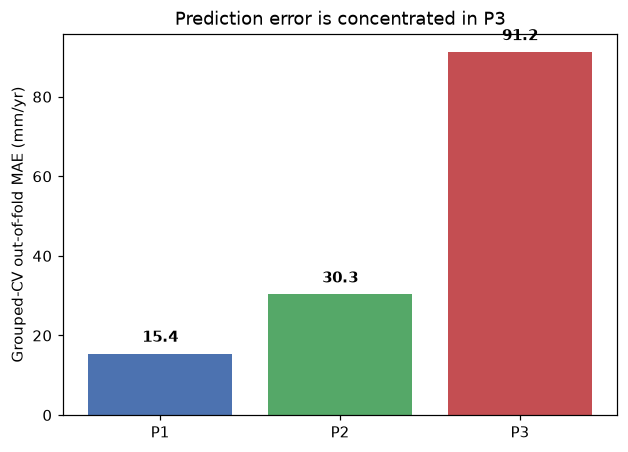

In [35]:
phase_error = error_strat[error_strat["Stratify_by"] == "Phase_Group"].copy()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(phase_error["Value"], phase_error["MAE"], color=["#4c72b0", "#55a868", "#c44e52"])
for i, (_, r) in enumerate(phase_error.iterrows()):
    ax.text(i, r["MAE"] + 3, f"{r['MAE']:.1f}", ha="center", fontweight="bold")
ax.set_ylabel("Grouped-CV out-of-fold MAE (mm/yr)")
ax.set_title("Prediction error is concentrated in P3")
save_fig(fig, "07_error_by_phase")
plt.show()


Error concentrates heavily in **P3 / Tafel / Basic-medium / high-temperature** segments
(MAE up to ~131 vs ~15-30 elsewhere) — the pooled model's moderate global performance is not evenly
distributed; it is substantially worse specifically where technique and medium differ most from the
majority of the training data (P1/P2, weight loss, acid).

### 9.6 — Model-simplicity test

Does the added complexity of Random Forest / XGBoost / CatBoost provide a meaningful gain over a
simple Ridge baseline (threshold: >0.05 R²)?

In [36]:
simplicity = pd.read_csv(ROOT / "Unified_Analysis" / "model_simplicity_test.csv")
simplicity


,Config,CV_scheme,Ridge_R2,Best_complex_model,Best_complex_R2,R2_gain_over_Ridge,meaningful_gain
0,A_P1,grouped_5fold,-1.664492,CatBoost,0.571457,2.235949,True
1,A_P1,standard_5fold,0.910973,XGBoost,0.982727,0.071754,True
2,B_P2,grouped_5fold,-3.801215,CatBoost,0.268554,4.069770,True
3,B_P2,standard_5fold,0.697933,XGBoost,0.969105,0.271172,True
4,C_P3,grouped_5fold,-5.060801,CatBoost,-5.104036,-0.043235,False
5,C_P3,standard_5fold,-3.442961,CatBoost,-1.614484,1.828477,True
6,D_P1P2,grouped_5fold,-0.318588,CatBoost,0.420603,0.739191,True
7,D_P1P2,standard_5fold,0.719454,CatBoost,0.971004,0.251550,True
8,E_P1P2P3,grouped_5fold,-0.985427,RandomForest,0.056523,1.041950,True
9,E_P1P2P3,standard_5fold,0.497846,RandomForest,0.620369,0.122524,True


Complex models beat Ridge meaningfully in **13 of 14** config×CV-scheme combinations. The one
exception is **P3 alone under grouped CV** — neither Ridge nor CatBoost works there, because the
underlying data (n=17/medium) simply cannot support any model at this sample size.

---
## Part 10 — Final Claim Audit: What Is Actually Supported?

Every major claim made anywhere in this research program is classified below as **Supported**,
**Conditional**, or **Not Supported**, based strictly on the evidence generated above. The full
question-by-question reasoning (32 reviewer questions in total) lives in
[`REVIEWER_CHALLENGES.md`](../REVIEWER_CHALLENGES.md).

| Original claim | Status |
|---|---|
| Temperature is the universal dominant driver of corrosion rate | **Conditional** — true for P1/P2 gravimetric phases only |
| P1 and P2 have convergent activation energies | **Supported** — formal statistical test, stable under sensitivity analysis |
| P3's activation energy also converges with P1/P2 | **Not supported** — excluded by design due to unstable fits |
| Ternary blend outperforms single inhibitor | **Not comparable** — different dosage units (mL vs ppm), no validated conversion |
| Tafel/P3 performs worse due to measurement technique | **Supported, but confounded** with P3's much smaller sample size |
| Combining all three phases improves prediction over P1+P2 alone | **Not supported** — performance decreases in most model/CV combinations |
| ML models generalize across experimental phases | **Conditional** — direction-dependent, explained by interpolation/extrapolation structure |
| Reported model performance could be due to chance | **Supported (not due to chance)** — passes permutation/null test |
| Model complexity (RF/XGBoost/CatBoost) is justified over Ridge | **Supported**, except where the data itself is unpredictable (P3 alone) |
| The model is learning corrosion physics, not phase identity | **Mostly supported** — identity features contribute minimally except when technique changes |
| Cross-phase generalization implies prediction of any unseen inhibitor chemistry | **Not supported / out of scope** — phase and inhibitor chemistry are fully confounded in this design |


---
## Part 11 — Conclusion and What's Next

**What this unified analysis actually contributes**, beyond what any single phase's original report
could show:

1. **A formally tested, chemistry-grounded convergence** in activation energy between two
   independently formulated green inhibitor systems (P1, P2) — the strongest single result in this
   research program.
2. **A quantified demonstration that naive random cross-validation substantially overstates model
   performance** in this kind of small, structured, replicate-heavy corrosion dataset — a
   methodological finding with implications well beyond this specific study.
3. **A direction-dependent, mechanistically explained picture of cross-phase generalization** — not a
   single "does it work" verdict, but a clear account of which variables must be extrapolated in each
   direction and why that predicts success or failure.
4. **An honest, quantified account of where this framework's predictions are weakest** (P3 / Tafel /
   Basic medium / high temperature) rather than a single global accuracy number that hides that weakness.

**What remains explicitly out of scope**: universal prediction of unseen inhibitor chemistries (the
current design confounds "new phase" with "new inhibitor"), any adsorption-thermodynamics claim (no
isotherm data was collected), and any claim that P3 by itself is a reliable predictive dataset at its
current sample size.

**Next steps**: build the 3-4 poster-ready figures from the CSVs generated in this folder (Ea bar
chart with error bars, standard-vs-grouped-CV comparison, leave-one-phase-out chart), finalize the
poster title and abstract per `POSTER_RESEARCH_SYNTHESIS.md`, and only pursue a full research paper
once those figures and the poster narrative are locked.
